In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import json
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.linear_model import LinearRegression
import calendar

# # # Load data and set directory

In [2]:
#Setting directory and read csv output from the GEE
belmontdir = "C:/Users/Nazia/Documents/OSU/Belmont/PlotData/"
doyNTL_allgrid3 = "allNTL_allgrid3_props.csv" 
df_allntl = pd.read_csv(belmontdir + doyNTL_allgrid3)

In [3]:
df_allntl.columns

Index(['settl_pcod', 'NTLmean', 'YYYY_MM_DD'], dtype='object')

In [4]:
print(df_allntl)

            settl_pcod   NTLmean  YYYY_MM_DD
0        MG11117000035  0.164565  2012-01-19
1        MG11117000050  0.177991  2012-01-19
2        MG11117000070  0.139347  2012-01-19
3        MG11117000080  0.124084  2012-01-19
4        MG11117000081  0.149829  2012-01-19
...                ...       ...         ...
2886760  MG72716000003  2.634741  2023-12-30
2886761  MG72716000206  0.215901  2023-12-30
2886762  MG72716000242  0.300109  2023-12-30
2886763  MG72716000429  0.683501  2023-12-30
2886764  MG72716000438  0.219506  2023-12-30

[2886765 rows x 3 columns]


In [5]:
# Convert 'YYYY_MM_DD' column to datetime
df_allntl['YYYY_MM_DD'] = pd.to_datetime(df_allntl['YYYY_MM_DD'])

# Display the first few rows to verify the conversion
print(df_allntl.head())


      settl_pcod   NTLmean YYYY_MM_DD
0  MG11117000035  0.164565 2012-01-19
1  MG11117000050  0.177991 2012-01-19
2  MG11117000070  0.139347 2012-01-19
3  MG11117000080  0.124084 2012-01-19
4  MG11117000081  0.149829 2012-01-19


In [6]:
# Pivot the table
df_date = df_allntl.pivot(index='settl_pcod', columns='YYYY_MM_DD', values='NTLmean')

# Save the modified DataFrame to a CSV file
output_file = belmontdir + "allNTL_allgrid3_datetime.csv"
df_date.to_csv(output_file, index=True)  # Set index=True to include 'settl_pcod' in the CSV

In [7]:
print(df_date.index.name)

settl_pcod


In [8]:
print(df_date.columns)

DatetimeIndex(['2012-01-19', '2012-01-20', '2012-01-21', '2012-01-22',
               '2012-01-23', '2012-01-24', '2012-01-25', '2012-01-26',
               '2012-01-27', '2012-01-28',
               ...
               '2023-12-21', '2023-12-22', '2023-12-23', '2023-12-24',
               '2023-12-25', '2023-12-26', '2023-12-27', '2023-12-28',
               '2023-12-29', '2023-12-30'],
              dtype='datetime64[ns]', name='YYYY_MM_DD', length=4341, freq=None)


In [9]:
print(df_date.index)

Index(['MG00000000032', 'MG00000000033', 'MG00000000037', 'MG00000000038',
       'MG11000000001', 'MG11000000005', 'MG11000000013', 'MG11000000022',
       'MG11000000030', 'MG11000000034',
       ...
       'MG72712000205', 'MG72712000225', 'MG72712000227', 'MG72716000001',
       'MG72716000002', 'MG72716000003', 'MG72716000206', 'MG72716000242',
       'MG72716000429', 'MG72716000438'],
      dtype='object', name='settl_pcod', length=665)


In [10]:
print(df_date)

YYYY_MM_DD     2012-01-19  2012-01-20  2012-01-21  2012-01-22  2012-01-23  \
settl_pcod                                                                  
MG00000000032    0.404007    0.382916    0.382916    0.392612    0.383080   
MG00000000033    0.472597    0.469730    0.469730    0.469730    0.469730   
MG00000000037    0.205324    0.177662    0.177662    0.177662    0.177662   
MG00000000038    0.213136    0.213136    0.213136    0.218590    0.213136   
MG11000000001    0.337185    0.337185    0.337185    0.337185    0.337185   
...                   ...         ...         ...         ...         ...   
MG72716000003    0.665745    0.679804    0.678874    0.929711    0.589105   
MG72716000206    0.117037    0.117037    0.117037    0.371347    0.150026   
MG72716000242    0.108261    0.108261    0.108261    0.431848    0.141630   
MG72716000429    0.085915    0.085915    0.085915    0.379577    0.113883   
MG72716000438    0.117284    0.117284    0.117284    0.257654    0.120370   

### Load Track Shapefile and Generate onset_df

In [11]:
# cyclone_track_gdf = gpd.read_file(belmontdir + "merged_jtwc_updated.shp")

# # Select columns to keep
# columns_to_keep = ['constant', 'datetime']
# onset_df = cyclone_track_gdf[columns_to_keep]

# # Rename columns
# onset_df = onset_df.rename(columns={'constant': 'Cyclone', 'datetime': 'Onset_DateTime'})

# # Capitalize all cyclone names
# onset_df['Cyclone'] = onset_df['Cyclone'].str.upper()

# # Convert Onset_DateTime to datetime format
# onset_df['Onset_DateTime'] = pd.to_datetime(onset_df['Onset_DateTime'])

# # Create a new column with only the date part
# onset_df['Onset_Date'] = onset_df['Onset_DateTime'].dt.date

# # Add 1 day to Onset_DateTime and store only the date part in a new column
# onset_df['Onset_Date_plus1d'] = (onset_df['Onset_DateTime'] + pd.Timedelta(days=1)).dt.date

# # Add 2 day to Onset_DateTime and store only the date part in a new column
# onset_df['Onset_Date_plus2d'] = (onset_df['Onset_DateTime'] + pd.Timedelta(days=2)).dt.date

# # Add 3 day to Onset_DateTime and store only the date part in a new column
# onset_df['Onset_Date_plus3d'] = (onset_df['Onset_DateTime'] + pd.Timedelta(days=3)).dt.date

# # Add 12 day to Onset_DateTime and store only the date part in a new column
# onset_df['Onset_Date_plus12d'] = (onset_df['Onset_DateTime'] + pd.Timedelta(days=12)).dt.date

# # Add 1 day to Onset_DateTime and store only the date part in a new column
# onset_df['Onset_Date_minus1d'] = (onset_df['Onset_DateTime'] + pd.Timedelta(days=-1)).dt.date

# # Print the columns to verify the changes
# print(onset_df.columns)
# print(onset_df.head())


In [16]:
cyclone_track_gdf = gpd.read_file(belmontdir + "merged_jtwc_updated.shp")

# Select columns to keep
columns_to_keep = ['constant', 'datetime']
landfall_df = cyclone_track_gdf[columns_to_keep]

# Rename columns
landfall_df = landfall_df.rename(columns={'constant': 'Cyclone', 'datetime': 'Landfall_DateTime'})

# Capitalize all cyclone names
landfall_df['Cyclone'] = landfall_df['Cyclone'].str.upper()

# Convert Landfall_DateTime to datetime format
landfall_df['Landfall_DateTime'] = pd.to_datetime(landfall_df['Landfall_DateTime'])

# Add 3 hours to the Landfall_DateTime column
landfall_df['Landfall_DateTime_Local'] = landfall_df['Landfall_DateTime'] + pd.Timedelta(hours=3)

# Create a new column with only the date part
landfall_df['Landfall_Date'] = landfall_df['Landfall_DateTime'].dt.date

# Print the columns to verify the changes
print(landfall_df)


     Cyclone   Landfall_DateTime Landfall_DateTime_Local Landfall_Date
0        ANA 2022-01-22 06:00:00     2022-01-22 09:00:00    2022-01-22
1        AVA 2018-01-04 12:00:00     2018-01-04 15:00:00    2018-01-04
2   BATSIRAI 2022-02-05 06:00:00     2022-02-05 09:00:00    2022-02-05
3      BELNA 2019-12-08 12:00:00     2019-12-08 15:00:00    2019-12-08
4    CHALANE 2020-12-26 12:00:00     2020-12-26 15:00:00    2020-12-26
5     CHANDA 2012-01-08 00:00:00     2012-01-08 03:00:00    2012-01-08
6     CHEDZA 2015-01-16 00:00:00     2015-01-16 03:00:00    2015-01-16
7    CHENESO 2023-01-18 18:00:00     2023-01-18 21:00:00    2023-01-18
8     DELIWE 2014-01-14 12:00:00     2014-01-14 15:00:00    2014-01-14
9     DUMAKO 2022-02-15 06:00:00     2022-02-15 09:00:00    2022-02-15
10   ELIAKIM 2018-03-15 18:00:00     2018-03-15 21:00:00    2018-03-15
11    ELOISE 2021-01-19 06:00:00     2021-01-19 09:00:00    2021-01-19
12    EMNATI 2022-02-22 06:00:00     2022-02-22 09:00:00    2022-02-22
13    

In [17]:
# Add 1 day to Onset_DateTime and store only the date part in a new column
landfall_df['Landfall_Date_plus1d'] = (landfall_df['Landfall_DateTime'] + pd.Timedelta(days=1)).dt.date

# Add 2 day to Onset_DateTime and store only the date part in a new column
landfall_df['Landfall_plus2d'] = (landfall_df['Landfall_DateTime'] + pd.Timedelta(days=2)).dt.date

# Add 3 day to Onset_DateTime and store only the date part in a new column
landfall_df['Landfall_Date_plus3d'] = (landfall_df['Landfall_DateTime'] + pd.Timedelta(days=3)).dt.date

# Add 12 day to Onset_DateTime and store only the date part in a new column
landfall_df['Landfall_Date_plus12d'] = (landfall_df['Landfall_DateTime'] + pd.Timedelta(days=12)).dt.date

In [19]:
print(landfall_df.head())

    Cyclone   Landfall_DateTime Landfall_DateTime_Local Landfall_Date  \
0       ANA 2022-01-22 06:00:00     2022-01-22 09:00:00    2022-01-22   
1       AVA 2018-01-04 12:00:00     2018-01-04 15:00:00    2018-01-04   
2  BATSIRAI 2022-02-05 06:00:00     2022-02-05 09:00:00    2022-02-05   
3     BELNA 2019-12-08 12:00:00     2019-12-08 15:00:00    2019-12-08   
4   CHALANE 2020-12-26 12:00:00     2020-12-26 15:00:00    2020-12-26   

  Landfall_Date_plus1d Landfall_plus2d Landfall_Date_plus3d  \
0           2022-01-23      2022-01-24           2022-01-25   
1           2018-01-05      2018-01-06           2018-01-07   
2           2022-02-06      2022-02-07           2022-02-08   
3           2019-12-09      2019-12-10           2019-12-11   
4           2020-12-27      2020-12-28           2020-12-29   

  Landfall_Date_plus12d  
0            2022-02-03  
1            2018-01-16  
2            2022-02-17  
3            2019-12-20  
4            2021-01-07  


In [21]:
# Ensure that 'Onset_Date' is in datetime format
landfall_df['Landfall_Date'] = pd.to_datetime(landfall_df['Landfall_Date'])

# Filter the DataFrame for rows where the year is 2012 or later
filtered_df = landfall_df[landfall_df['Landfall_Date'] >= pd.to_datetime('2012-01-19')]

# Extract unique cyclone names
Blck_Mrbl_unique = filtered_df['Cyclone'].unique()

# Print the unique cyclone names
print(Blck_Mrbl_unique)
print(len(Blck_Mrbl_unique))

['ANA' 'AVA' 'BATSIRAI' 'BELNA' 'CHALANE' 'CHEDZA' 'CHENESO' 'DELIWE'
 'DUMAKO' 'ELIAKIM' 'ELOISE' 'EMNATI' 'ENAWO' 'FAKIR' 'FREDDY' 'FUNDI'
 'GIOVANNA' 'GOMBE' 'HALIBA' 'HARUNA' 'HELEN' 'HEROLD' 'IDAI' 'IRINA'
 'JASMINE' 'JOBO' 'KENNETH']
27


## One Cyclone, One Settlement Cyclone Time Series

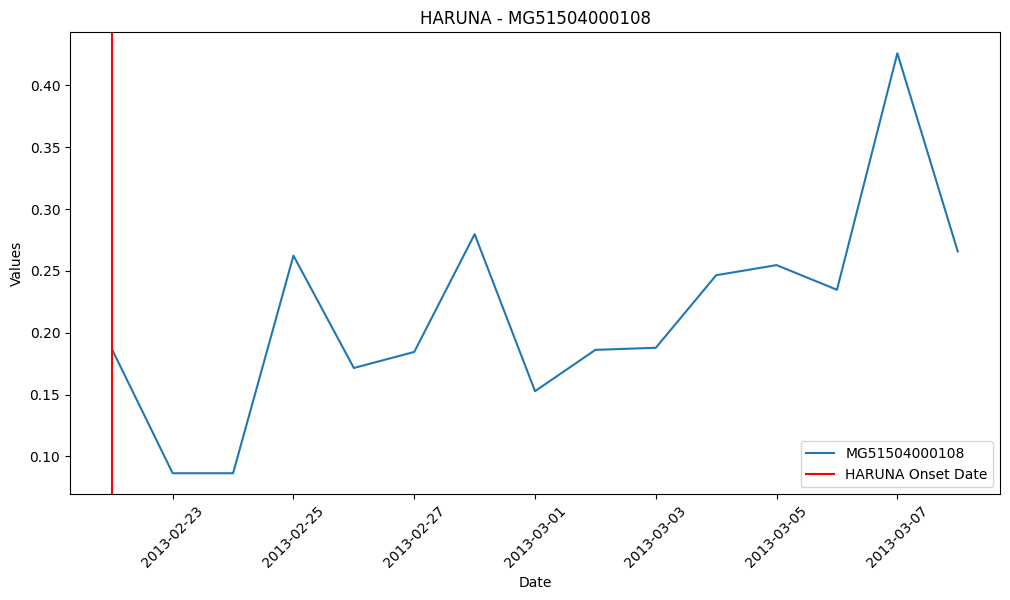

In [83]:
# Set the cyclone name and the number of days for the time delta
cyclone_name = 'HARUNA'
lag = 14

# Grid value
grid3 = 'MG51504000108'

# Check if the cyclone exists in the landfall_df
if cyclone_name in landfall_df['Cyclone'].values:
    # Get the onset date for the cyclone
    cyclone_onset = landfall_df.loc[landfall_df['Cyclone'] == cyclone_name, 'Landfall_Date_plus1d'].values[0]

    # Convert the onset date to datetime
    cyclone_onset = pd.to_datetime(cyclone_onset)

    # Select the range of dates (2 weeks before and 2 weeks after cyclone onset)
    range_end = cyclone_onset + pd.Timedelta(days=lag)
    date_range = pd.date_range(start=cyclone_onset, end=range_end)

    # Check if 'grid3' value is in the DataFrame index and plot the data for it
    if grid3 in df_date.index:
        # Extract the row for 'grid3'
        specific_row = df_date.loc[grid3, date_range]

        # Plotting
        plt.figure(figsize=(12, 6))
        plt.plot(date_range, specific_row, label=grid3)

        plt.title(f'{cyclone_name} - {grid3}')
        plt.xlabel('Date')
        plt.ylabel('Values')
        plt.xticks(rotation=45)
        plt.axvline(x=cyclone_onset, color='r', linestyle='-', label=f'{cyclone_name} Onset Date')
        plt.legend()
        plt.show()
    else:
        print(f"Row with '{grid3}' not found.")
else:
    print(f"Onset date for '{cyclone_name}' cyclone not found in the landfall_df.")


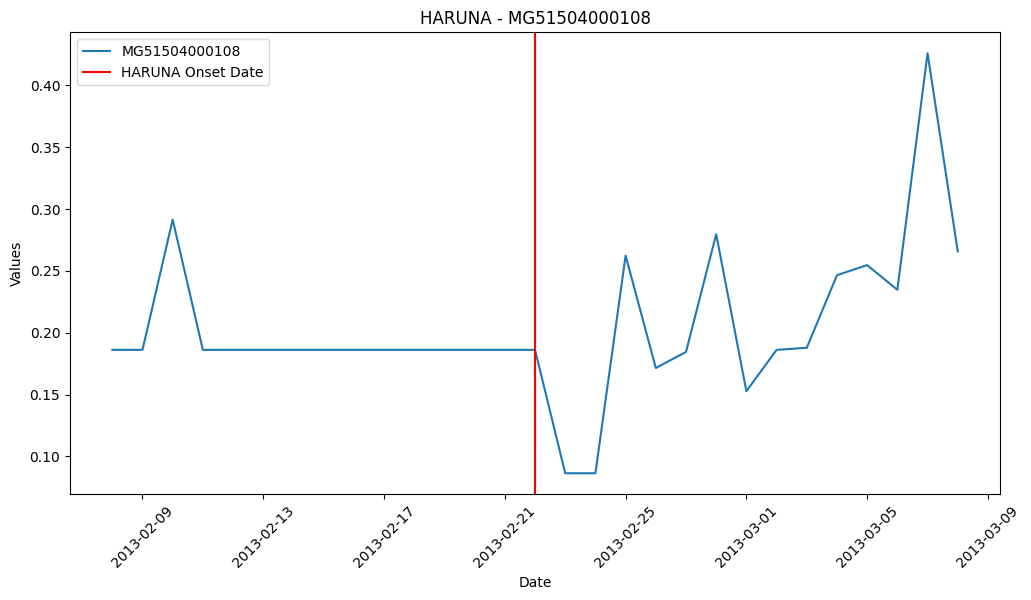

In [84]:
# Check if the cyclone exists in the landfall_df
if cyclone_name in landfall_df['Cyclone'].values:
    # Get the onset date for the cyclone
    cyclone_onset = landfall_df.loc[landfall_df['Cyclone'] == cyclone_name, 'Landfall_Date_plus1d'].values[0]

    # Convert the onset date to datetime
    cyclone_onset = pd.to_datetime(cyclone_onset)

    # Select the range of dates (lag days before and after cyclone onset)
    start_date = cyclone_onset - pd.Timedelta(days=lag)
    end_date = cyclone_onset + pd.Timedelta(days=lag)
    date_range = pd.date_range(start=start_date, end=end_date)

    # Check if 'grid3' value is in the DataFrame index and plot the data for it
    if grid3 in df_date.index:
        # Extract the row for 'grid3'
        specific_row = df_date.loc[grid3, date_range]

        # Plotting
        plt.figure(figsize=(12, 6))
        plt.plot(date_range, specific_row, label=grid3)

        plt.title(f'{cyclone_name} - {grid3}')
        plt.xlabel('Date')
        plt.ylabel('Values')
        plt.xticks(rotation=45)
        plt.axvline(x=cyclone_onset, color='r', linestyle='-', label=f'{cyclone_name} Onset Date')
        plt.legend()
        plt.show()
    else:
        print(f"Row with '{grid3}' not found.")
else:
    print(f"Onset date for '{cyclone_name}' cyclone not found in the landfall_df.")


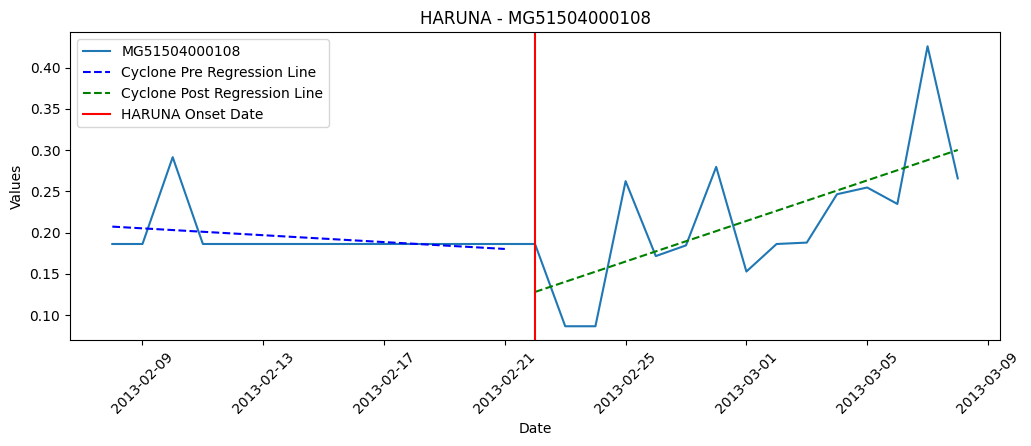

In [85]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Check if the cyclone exists in the landfall_df
if cyclone_name in landfall_df['Cyclone'].values:
    # Get the onset date for the cyclone
    cyclone_onset = landfall_df.loc[landfall_df['Cyclone'] == cyclone_name, 'Landfall_Date_plus1d'].values[0]

    # Convert the onset date to datetime
    cyclone_onset = pd.to_datetime(cyclone_onset)

    # Select the range of dates (lag days before and after cyclone onset)
    start_date = cyclone_onset - pd.Timedelta(days=lag)
    end_date = cyclone_onset + pd.Timedelta(days=lag)
    date_range = pd.date_range(start=start_date, end=end_date)

    # Check if 'grid3' value is in the DataFrame index and plot the data for it
    if grid3 in df_date.index:
        # Extract the row for 'grid3'
        specific_row = df_date.loc[grid3, date_range]

        # Plotting
        plt.figure(figsize=(12, 4))
        plt.plot(date_range, specific_row, label=grid3)

        # Calculate linear regression for pre and post periods
        pre_data = specific_row.loc[date_range < cyclone_onset]
        post_data = specific_row.loc[date_range >= cyclone_onset]
        X_pre = np.arange(len(pre_data)).reshape(-1, 1)
        y_pre = pre_data.values.reshape(-1, 1)
        X_post = np.arange(len(post_data)).reshape(-1, 1)
        y_post = post_data.values.reshape(-1, 1)

        # Fit linear regression models
        model_pre = LinearRegression()
        model_post = LinearRegression()
        model_pre.fit(X_pre, y_pre)
        model_post.fit(X_post, y_post)

        # Plot regression lines
        plt.plot(date_range[:len(pre_data)], model_pre.predict(X_pre), color='blue', linestyle='--', label='Cyclone Pre Regression Line')
        plt.plot(date_range[-len(post_data):], model_post.predict(X_post), color='green', linestyle='--', label='Cyclone Post Regression Line')

        plt.title(f'{cyclone_name} - {grid3}')
        plt.xlabel('Date')
        plt.ylabel('Values')
        plt.xticks(rotation=45)
        plt.axvline(x=cyclone_onset, color='r', linestyle='-', label=f'{cyclone_name} Onset Date')
        plt.legend()
        plt.show()
    else:
        print(f"Row with '{grid3}' not found.")
else:
    print(f"Onset date for '{cyclone_name}' cyclone not found in the landfall_df.")


## One Cyclone, One Settlement Seasonal trend

C:\Users\Nazia\AppData\Local\Temp\ipykernel_35160\595741692.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(tick_labels, rotation=45)


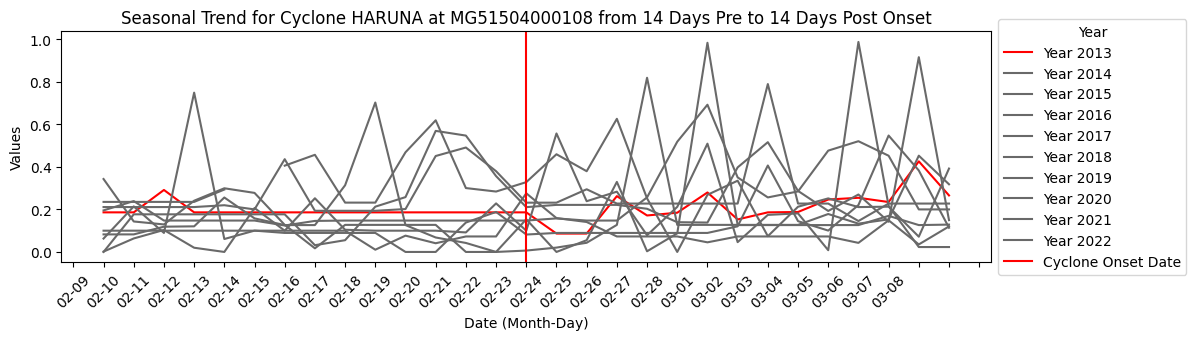

In [86]:
# Check if the cyclone exists in the landfall_df
if cyclone_name in landfall_df['Cyclone'].values:
    # Prepare the plot
    plt.figure(figsize=(12, 3))
    ax = plt.gca()

    # Get the onset date for the cyclone
    cyclone_onset = pd.to_datetime(landfall_df.loc[landfall_df['Cyclone'] == cyclone_name, 'Landfall_Date_plus1d'].values[0])

    # Convert columns to DateTime to enable filtering by date
    df_date.columns = pd.to_datetime(df_date.columns)

    # Loop through the desired years
    for year in range(2013, 2023):  # Modify the range as needed
        # Set the onset date for the current year
        current_year_onset = cyclone_onset.replace(year=year)

        # Define the start and end dates based on the lag
        start_date = current_year_onset - pd.Timedelta(days=lag)
        end_date = current_year_onset + pd.Timedelta(days=lag)

        # Filter data for the specific 'settl_pcod' and date range
        if grid3 in df_date.index:
            # Select the data for the specific 'settl_pcod'
            specific_data = df_date.loc[grid3]
            
            # Filter the data to include only the specified period around the onset date
            specific_data = specific_data[(specific_data.index >= start_date) & (specific_data.index <= end_date)]

            # Choose color based on the year
            color = 'red' if year == cyclone_onset.year else 'dimgrey'

            # Plot the data for the specific year with a unique label
            ax.plot(range(len(specific_data)), specific_data, label=f'Year {year}', color=color)

    # Set the x-axis ticks and labels
    total_days = 2 * lag + 1
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))  # Set major ticks every day
    tick_labels = [(cyclone_onset - pd.Timedelta(days=lag) + pd.Timedelta(days=i)).strftime('%m-%d') for i in range(total_days)]
    ax.set_xticklabels(tick_labels, rotation=45)

    # Adding a vertical red line at the onset date
    ax.axvline(lag, color='red', linestyle='-', label='Cyclone Onset Date')  # Onset date is at position 'lag' in the range

    # Title and labels
    plt.title(f'Seasonal Trend for Cyclone {cyclone_name} at {grid3} from {lag} Days Pre to {lag} Days Post Onset')
    plt.xlabel('Date (Month-Day)')
    plt.ylabel('Values')

    # Show the legend
    plt.legend(title='Year')

     # Adjust the legend position to the right of the plot
    ax.legend(title='Year', loc='center left', bbox_to_anchor=(1, 0.5))

    # Show the plot
    plt.show()
else:
    print(f"Cyclone name '{cyclone_name}' not found in the dataset.")

C:\Users\Nazia\AppData\Local\Temp\ipykernel_35160\2944339171.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Set2', len(years))
C:\Users\Nazia\AppData\Local\Temp\ipykernel_35160\2944339171.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(tick_labels, rotation=45)


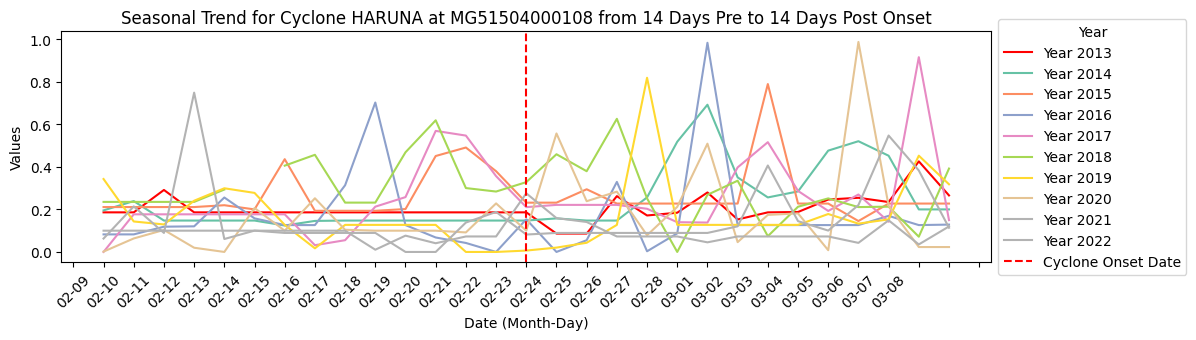

In [87]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Assuming 'landfall_df' and 'df_date' are pre-loaded DataFrames and 'cyclone_name', 'grid3', and 'lag' are defined variables

# Check if the cyclone exists in the landfall_df
if cyclone_name in landfall_df['Cyclone'].values:
    # Prepare the plot
    plt.figure(figsize=(12, 3))
    ax = plt.gca()

    # Get the onset date for the cyclone
    cyclone_onset = pd.to_datetime(landfall_df.loc[landfall_df['Cyclone'] == cyclone_name, 'Landfall_Date_plus1d'].values[0])

    # Convert columns to DateTime to enable filtering by date
    df_date.columns = pd.to_datetime(df_date.columns)

    # Define the range of years and create a color map
    years = range(2013, 2023)  # Modify the range as needed
    cmap = cm.get_cmap('Set2', len(years))
    norm = mcolors.Normalize(vmin=years[0], vmax=years[-1])

    # Loop through the desired years
    for year in years:
        # Set the onset date for the current year
        current_year_onset = cyclone_onset.replace(year=year)

        # Define the start and end dates based on the lag
        start_date = current_year_onset - pd.Timedelta(days=lag)
        end_date = current_year_onset + pd.Timedelta(days=lag)

        # Filter data for the specific 'settl_pcod' and date range
        if grid3 in df_date.index:
            # Select the data for the specific 'settl_pcod'
            specific_data = df_date.loc[grid3]
            
            # Filter the data to include only the specified period around the onset date
            specific_data = specific_data[(specific_data.index >= start_date) & (specific_data.index <= end_date)]

            # Choose color based on the year
            color = 'red' if year == cyclone_onset.year else cmap(norm(year))

            # Plot the data for the specific year with a unique label
            ax.plot(range(len(specific_data)), specific_data, label=f'Year {year}', color=color)

    # Set the x-axis ticks and labels
    total_days = 2 * lag + 1
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))  # Set major ticks every day
    tick_labels = [(cyclone_onset - pd.Timedelta(days=lag) + pd.Timedelta(days=i)).strftime('%m-%d') for i in range(total_days)]
    ax.set_xticklabels(tick_labels, rotation=45)

    # Adding a vertical red line at the onset date
    ax.axvline(lag, color='red', linestyle='--', label='Cyclone Onset Date')  # Onset date is at position 'lag' in the range

    # Title and labels
    plt.title(f'Seasonal Trend for Cyclone {cyclone_name} at {grid3} from {lag} Days Pre to {lag} Days Post Onset')
    plt.xlabel('Date (Month-Day)')
    plt.ylabel('Values')

    # Show the legend
    plt.legend(title='Year')

    # Adjust the legend position to the right of the plot
    ax.legend(title='Year', loc='center left', bbox_to_anchor=(1, 0.5))

    # Show the plot
    plt.show()
else:
    print(f"Cyclone name '{cyclone_name}' not found in the dataset.")


### One Cyclone, One Settlement Seasonal trend (Only Freddy Error plotting in 2023)

C:\Users\Nazia\AppData\Local\Temp\ipykernel_35160\3860291495.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Set2', len(years))
C:\Users\Nazia\AppData\Local\Temp\ipykernel_35160\3860291495.py:74: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(tick_labels, rotation=45)


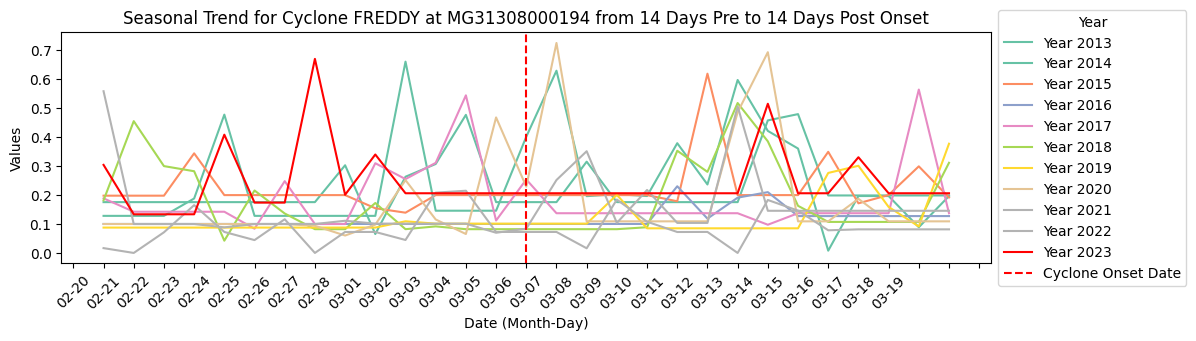

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Assuming these DataFrames are already loaded and contain the necessary data:
# landfall_df, df_date
# Also assuming 'cyclone_name', 'lag', and 'grid3' variables are defined

# Check if the cyclone exists in the landfall_df
if cyclone_name in landfall_df['Cyclone'].values:
    # Prepare the plot
    plt.figure(figsize=(12, 3))
    ax = plt.gca()

    # Get the onset date for the cyclone
    cyclone_onset = pd.to_datetime(landfall_df.loc[landfall_df['Cyclone'] == cyclone_name, 'Landfall_Date_plus12d'].values[0])

    # Convert columns to DateTime to enable filtering by date
    df_date.columns = pd.to_datetime(df_date.columns)

    # Define the range of years and create a color map
    years = list(range(2013, 2023))  # Modify the range as needed
    cmap = cm.get_cmap('Set2', len(years))
    norm = mcolors.Normalize(vmin=years[0], vmax=years[-1])

    # Check if 'grid3' exists in the DataFrame index
    if grid3 not in df_date.index:
        print(f"Grid '{grid3}' not found in df_date index.")
    else:
        # Loop through the desired years
        for year in years:
            # Set the onset date for the current year
            current_year_onset = cyclone_onset.replace(year=year)

            # Define the start and end dates based on the lag
            start_date = current_year_onset - pd.Timedelta(days=lag)
            end_date = current_year_onset + pd.Timedelta(days=lag)

            # Select the data for the specific 'grid3'
            specific_data = df_date.loc[grid3]

            # Filter the data to include only the specified period around the onset date
            specific_data_filtered = specific_data.loc[start_date:end_date]

            # Ensure the filtered data is not empty
            if not specific_data_filtered.empty:
                # Choose color based on the year
                color = 'blue' if year == 2023 else cmap(norm(year))

                # Plot the data for the specific year with a unique label
                ax.plot(range(len(specific_data_filtered)), specific_data_filtered, label=f'Year {year}', color=color)
            else:
                print(f"No data available for year {year} in the specified date range.")

        # Explicitly check and plot data for the year 2023
        current_year_onset = cyclone_onset.replace(year=2023)
        start_date = current_year_onset - pd.Timedelta(days=lag)
        end_date = current_year_onset + pd.Timedelta(days=lag)
        specific_data_2023 = df_date.loc[grid3].loc[start_date:end_date]

        # Ensure the filtered data is not empty and plot data for 2023
        if not specific_data_2023.empty:
            ax.plot(range(len(specific_data_2023)), specific_data_2023, label='Year 2023', color='red')
        else:
            print(f"No data available for year 2023 in the specified date range.")

        # Set the x-axis ticks and labels
        total_days = 2 * lag + 1
        ax.xaxis.set_major_locator(ticker.MultipleLocator(1))  # Set major ticks every day
        tick_labels = [(cyclone_onset - pd.Timedelta(days=lag) + pd.Timedelta(days=i)).strftime('%m-%d') for i in range(total_days)]
        ax.set_xticklabels(tick_labels, rotation=45)

        # Adding a vertical red line at the onset date
        ax.axvline(lag, color='red', linestyle='--', label='Cyclone Onset Date')  # Onset date is at position 'lag' in the range

        # Title and labels
        plt.title(f'Seasonal Trend for Cyclone {cyclone_name} at {grid3} from {lag} Days Pre to {lag} Days Post Onset')
        plt.xlabel('Date (Month-Day)')
        plt.ylabel('Values')

        # Show the legend
        plt.legend(title='Year')

        # Adjust the legend position to the right of the plot
        ax.legend(title='Year', loc='center left', bbox_to_anchor=(1, 0.5))

        # Show the plot
        plt.show()
else:
    print(f"Cyclone name '{cyclone_name}' not found in the dataset.")


# ### Creating df for holding the data of historic averages

In [40]:
# # Set the cyclone name and the number of days for the time delta
# cyclone_name = 'BATSIRAI'
# lag = 14

# # Grid value
# grid3 = 'MG21224000157'


In [41]:
import pandas as pd
import calendar

# Check if the cyclone exists in the landfall_df
if cyclone_name in landfall_df['Cyclone'].values:
    # Initialize an empty DataFrame to store the average values
    hist_avg_df = pd.DataFrame()

    # Get the onset date for the cyclone
    cyclone_onset = pd.to_datetime(landfall_df.loc[landfall_df['Cyclone'] == cyclone_name, 'Onset_Date_plus1d'].values[0])

    # Calculate averages for each date from 2013 to 2021
    for year in range(2013, 2022):
        # Loop through the desired months and dates
        for month in range(1, 13):
            # Get the number of days in the month
            num_days = calendar.monthrange(year, month)[1]

            for day in range(1, num_days + 1):
                # Construct the date string
                current_date = pd.to_datetime(f"{year}-{month:02d}-{day:02d}")

                # Select the data for the specific 'settl_pcod'
                if grid3 in df_date.index:
                    specific_data = df_date.loc[grid3, current_date.strftime('%Y-%m-%d')]

                    # Store the average value in the DataFrame
                    hist_avg_df.at[f'{month:02d}-{day:02d}', year] = specific_data.mean()

    # Calculate the overall average for each date across the years
    hist_avg_df[f'{cyclone_name} Historical Average'] = hist_avg_df.mean(axis=1)

    # Display the DataFrame
    print(hist_avg_df)

else:
    print(f"Cyclone name '{cyclone_name}' not found in the dataset.")

           2013      2014      2015      2016      2017      2018      2019  \
01-01  2.352318  3.950510  2.404834  3.628278  2.939220  3.146645  2.266508   
01-02  3.089383  1.925521  2.404834  2.539871  4.116923  2.016761  3.101833   
01-03  2.536439  1.911810  2.404834  1.915469  3.211368  2.122307  1.803995   
01-04  1.851975  2.517434  2.009474  2.407437  2.923541  2.876161  2.974498   
01-05  1.738993  3.385926  2.387513  2.722663  2.065526  3.542601  2.974498   
...         ...       ...       ...       ...       ...       ...       ...   
12-28  2.593284  1.944918  1.707628  3.586960  2.398376  3.160767  2.747475   
12-29  2.593284  2.757183  1.625560  3.557730  2.360767  3.910930  1.955705   
12-30  3.071113  2.404834  2.694761  2.495227  2.909963  3.023499  2.635256   
12-31  5.794889  2.424216  3.559256  2.927260  4.179292  3.002505  6.291995   
02-29       NaN       NaN       NaN  3.051752       NaN       NaN       NaN   

           2020      2021  BATSIRAI Historical Aver

### Individual cyclone and grid3

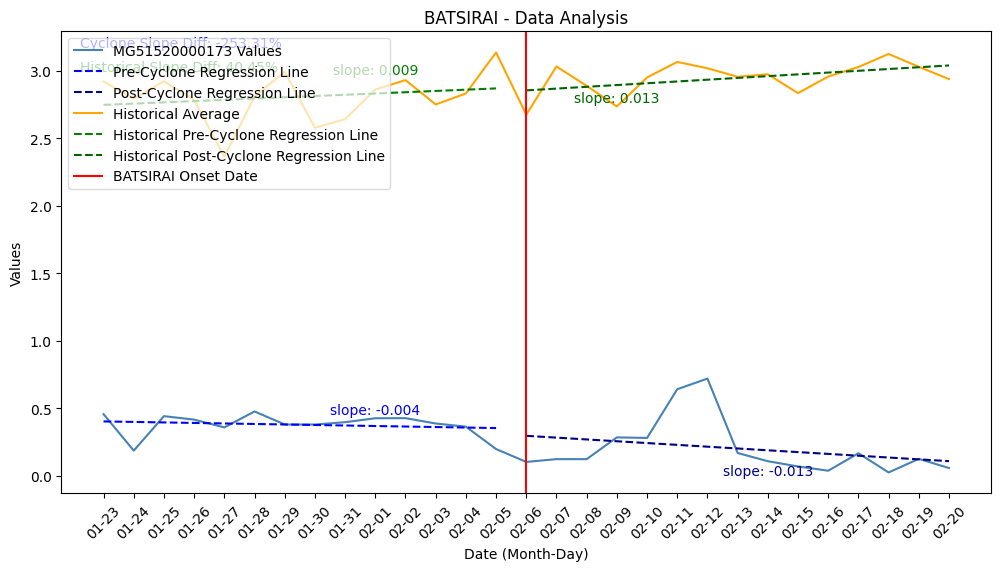

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.linear_model import LinearRegression

# Set the cyclone name and the number of days for the time delta
cyclone_name = 'BATSIRAI'
lag = 14

# Grid value
grid3 = 'MG51520000173'

# Assuming the necessary data is already loaded into landfall_df, df_date, and hist_avg_df
if cyclone_name in landfall_df['Cyclone'].values:
    cyclone_onset = pd.to_datetime(landfall_df.loc[landfall_df['Cyclone'] == cyclone_name, 'Onset_Date_plus1d'].values[0])
    cyclone_onset_str = cyclone_onset.strftime('%m-%d')
    start_date = cyclone_onset - pd.Timedelta(days=lag)
    end_date = cyclone_onset + pd.Timedelta(days=lag)
    date_range = pd.date_range(start=start_date, end=end_date)

    plt.figure(figsize=(12, 6))

    if grid3 in df_date.index:
        specific_row = df_date.loc[grid3, date_range]
        plt.plot([date.strftime('%m-%d') for date in date_range], specific_row, label=f'{grid3} Values', color='steelblue')

        pre_data_grid3 = specific_row[date_range < cyclone_onset]
        post_data_grid3 = specific_row[date_range >= cyclone_onset]

        X_pre_grid3 = np.arange(len(pre_data_grid3)).reshape(-1, 1)
        y_pre_grid3 = pre_data_grid3.values.reshape(-1, 1)
        X_post_grid3 = np.arange(len(post_data_grid3)).reshape(-1, 1)
        y_post_grid3 = post_data_grid3.values.reshape(-1, 1)

        model_pre_grid3 = LinearRegression().fit(X_pre_grid3, y_pre_grid3)
        model_post_grid3 = LinearRegression().fit(X_post_grid3, y_post_grid3)

        slope_pre_grid3 = model_pre_grid3.coef_[0][0]
        slope_post_grid3 = model_post_grid3.coef_[0][0]

        plt.plot([date.strftime('%m-%d') for date in date_range[:len(pre_data_grid3)]], model_pre_grid3.predict(X_pre_grid3), linestyle='--', color='blue', label='Pre-Cyclone Regression Line')
        plt.plot([date.strftime('%m-%d') for date in date_range[-len(post_data_grid3):]], model_post_grid3.predict(X_post_grid3), linestyle='--', color='darkblue', label='Post-Cyclone Regression Line')

    avg_data = hist_avg_df.loc[hist_avg_df.index.isin([date.strftime('%m-%d') for date in date_range]), 'BATSIRAI Historical Average']
    plt.plot(avg_data.index, avg_data, label='Historical Average', color='orange')

    pre_data_hist = avg_data[date_range < cyclone_onset]
    post_data_hist = avg_data[date_range >= cyclone_onset]

    X_pre_hist = np.arange(len(pre_data_hist)).reshape(-1, 1)
    y_pre_hist = pre_data_hist.values.reshape(-1, 1)
    X_post_hist = np.arange(len(post_data_hist)).reshape(-1, 1)
    y_post_hist = post_data_hist.values.reshape(-1, 1)

    model_pre_hist = LinearRegression().fit(X_pre_hist, y_pre_hist)
    model_post_hist = LinearRegression().fit(X_post_hist, y_post_hist)

    slope_pre_hist = model_pre_hist.coef_[0][0]
    slope_post_hist = model_post_hist.coef_[0][0]

    plt.plot([date.strftime('%m-%d') for date in date_range[:len(pre_data_hist)]], model_pre_hist.predict(X_pre_hist), linestyle='--', color='green', label='Historical Pre-Cyclone Regression Line')
    plt.plot([date.strftime('%m-%d') for date in date_range[-len(post_data_hist):]], model_post_hist.predict(X_post_hist), linestyle='--', color='darkgreen', label='Historical Post-Cyclone Regression Line')

    cyclone_slope_diff_percent = (slope_post_grid3 - slope_pre_grid3) / abs(slope_pre_grid3) * 100
    hist_slope_diff_percent = (slope_post_hist - slope_pre_hist) / abs(slope_pre_hist) * 100

    # Annotations for slope percent differences
    plt.annotate(f'Cyclone Slope Diff: {cyclone_slope_diff_percent:.2f}%', xy=(0.02, 0.95), xycoords='axes fraction', textcoords="offset points", xytext=(0,5), ha='left', color='blue')
    plt.annotate(f'Historical Slope Diff: {hist_slope_diff_percent:.2f}%', xy=(0.02, 0.90), xycoords='axes fraction', textcoords="offset points", xytext=(0,5), ha='left', color='green')

    # Ensure pre_dates and post_dates are correctly defined
    pre_dates_str = [date.strftime('%m-%d') for date in date_range[:len(pre_data_grid3)]]
    post_dates_str = [date.strftime('%m-%d') for date in date_range[-len(post_data_grid3):]]

    # Convert dates for annotation positioning
    pre_date_for_annotation = pre_dates_str[-5]
    post_date_for_annotation = post_dates_str[8]

    # Annotation for slopes with corrected placement
    plt.annotate(f'slope: {slope_pre_grid3:.3f}', xy=(pre_date_for_annotation, model_pre_grid3.predict(X_pre_grid3)[-1][0]), xycoords='data', textcoords="offset points", xytext=(0,10), ha='center', color='blue')
    plt.annotate(f'slope: {slope_post_grid3:.3f}', xy=(post_date_for_annotation, model_post_grid3.predict(X_post_grid3)[-1][0]), xycoords='data', textcoords="offset points", xytext=(0,-10), ha='center', color='darkblue')

    # Assuming pre_hist_dates and post_hist_dates are similarly defined arrays/lists for the historical data
    pre_hist_dates_str = [date.strftime('%m-%d') for date in date_range[:len(pre_data_hist)]]
    post_hist_dates_str = [date.strftime('%m-%d') for date in date_range[-len(post_data_hist):]]

    # Correcting the historical annotations
    plt.annotate(f'slope: {slope_pre_hist:.3f}', xy=(pre_hist_dates_str[-5], model_pre_hist.predict(X_pre_hist)[-1][0]), xycoords='data', textcoords="offset points", xytext=(0,10), ha='center', color='green')
    plt.annotate(f'slope: {slope_post_hist:.3f}', xy=(post_hist_dates_str[3], model_post_hist.predict(X_post_hist)[1][0]), xycoords='data', textcoords="offset points", xytext=(0,-10), ha='center', color='darkgreen')

    plt.title(f'{cyclone_name} - Data Analysis')
    plt.xlabel('Date (Month-Day)')
    plt.ylabel('Values')
    plt.xticks(rotation=45)
    plt.axvline(x=cyclone_onset_str, color='red', linestyle='-', label=f'{cyclone_name} Onset Date')

    # Show the legend with transparency to ensure annotations are visible
    plt.legend(loc='upper left', framealpha=0.7)

    # Save the figure
    plt.savefig('cyclone_data_analysis.png', dpi=300)  # Adjust the path as needed

    plt.show()

else:
    print(f"Cyclone name '{cyclone_name}' not found in the dataset.")


## Individual cyclone and multiple grid3 historical trend

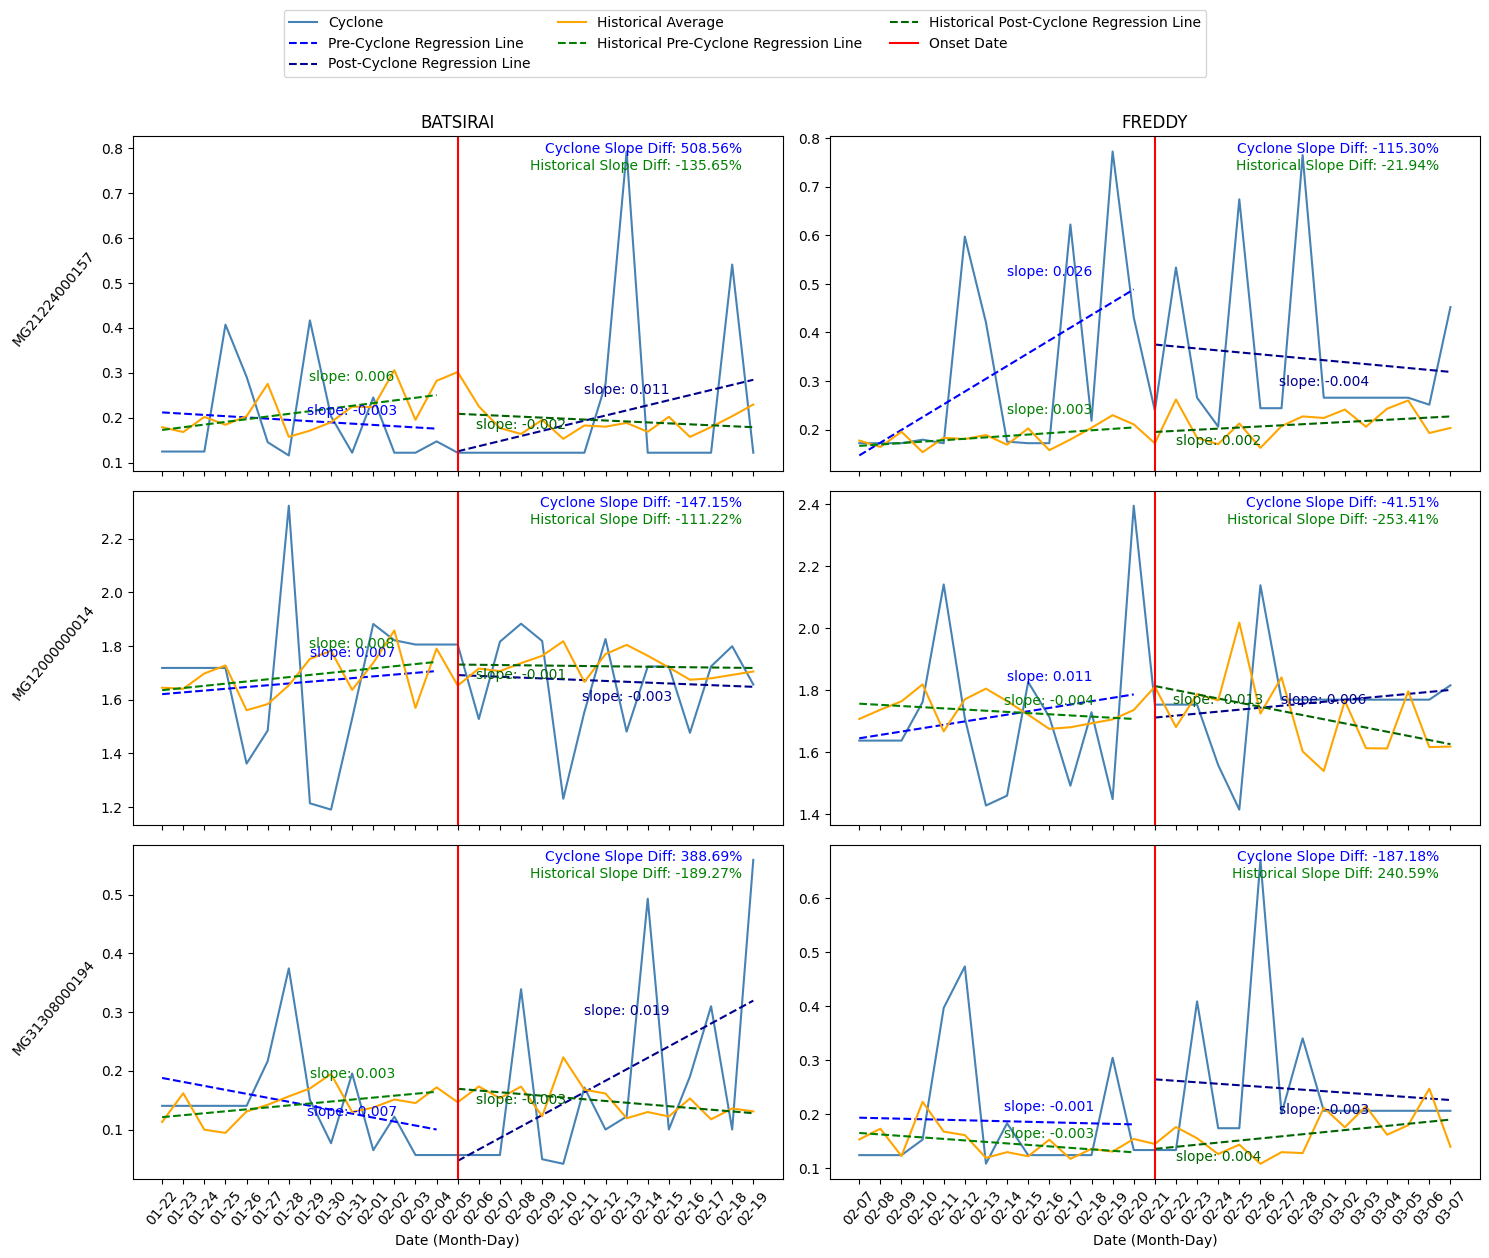

In [44]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import calendar
# from sklearn.linear_model import LinearRegression

# # Set the cyclone names and the number of days for the time delta
# cyclone_names = ['BATSIRAI', 'FREDDY']
# lag = 14

# # Grid values
# grids = ['MG21224000157', 'MG12000000014', 'MG31308000194']

# # Calculate historical averages
# def calculate_historical_average(df_date, grid3):
#     hist_avg_df = pd.DataFrame()
#     for year in range(2013, 2022):
#         for month in range(1, 13):
#             num_days = calendar.monthrange(year, month)[1]
#             for day in range(1, num_days + 1):
#                 current_date = pd.to_datetime(f"{year}-{month:02d}-{day:02d}")
#                 if grid3 in df_date.index:
#                     specific_data = df_date.loc[grid3, current_date.strftime('%Y-%m-%d')]
#                     hist_avg_df.at[f'{month:02d}-{day:02d}', year] = specific_data.mean()
#     hist_avg_df[f'{cyclone_name} Historical Average'] = hist_avg_df.mean(axis=1)
#     return hist_avg_df

# # Assuming the necessary data is already loaded into landfall_df and df_date
# fig, axs = plt.subplots(len(grids), len(cyclone_names), figsize=(15, len(grids) * 4), sharex='col')

# for j, cyclone_name in enumerate(cyclone_names):
#     if cyclone_name in landfall_df['Cyclone'].values:
#         cyclone_onset = pd.to_datetime(landfall_df.loc[landfall_df['Cyclone'] == cyclone_name, 'Onset_Date'].values[0])
#         cyclone_onset_str = cyclone_onset.strftime('%m-%d')
#         start_date = cyclone_onset - pd.Timedelta(days=lag)
#         end_date = cyclone_onset + pd.Timedelta(days=lag)
#         date_range = pd.date_range(start=start_date, end=end_date)

#         for i, grid3 in enumerate(grids):
#             ax = axs[i, j]

#             if grid3 not in df_date.index:
#                 print(f"Grid '{grid3}' not found in the dataset.")
#                 continue

#             specific_row = df_date.loc[grid3, date_range]

#             # Plot grid values
#             ax.plot([date.strftime('%m-%d') for date in date_range], specific_row, label='Cyclone', color='steelblue')

#             pre_data_grid3 = specific_row[date_range < cyclone_onset]
#             post_data_grid3 = specific_row[date_range >= cyclone_onset]

#             X_pre_grid3 = np.arange(len(pre_data_grid3)).reshape(-1, 1)
#             y_pre_grid3 = pre_data_grid3.values.reshape(-1, 1)
#             X_post_grid3 = np.arange(len(post_data_grid3)).reshape(-1, 1)
#             y_post_grid3 = post_data_grid3.values.reshape(-1, 1)

#             model_pre_grid3 = LinearRegression().fit(X_pre_grid3, y_pre_grid3)
#             model_post_grid3 = LinearRegression().fit(X_post_grid3, y_post_grid3)

#             slope_pre_grid3 = model_pre_grid3.coef_[0][0]
#             slope_post_grid3 = model_post_grid3.coef_[0][0]

#             ax.plot([date.strftime('%m-%d') for date in date_range[:len(pre_data_grid3)]], model_pre_grid3.predict(X_pre_grid3), linestyle='--', color='blue', label='Pre-Cyclone Regression Line')
#             ax.plot([date.strftime('%m-%d') for date in date_range[-len(post_data_grid3):]], model_post_grid3.predict(X_post_grid3), linestyle='--', color='darkblue', label='Post-Cyclone Regression Line')

#             # Calculate historical averages
#             hist_avg_df = calculate_historical_average(df_date, grid3)
#             avg_data = hist_avg_df.loc[hist_avg_df.index.isin([date.strftime('%m-%d') for date in date_range]), f'{cyclone_name} Historical Average']
#             ax.plot(avg_data.index, avg_data, label='Historical Average', color='orange')

#             pre_data_hist = avg_data[date_range < cyclone_onset]
#             post_data_hist = avg_data[date_range >= cyclone_onset]

#             X_pre_hist = np.arange(len(pre_data_hist)).reshape(-1, 1)
#             y_pre_hist = pre_data_hist.values.reshape(-1, 1)
#             X_post_hist = np.arange(len(post_data_hist)).reshape(-1, 1)
#             y_post_hist = post_data_hist.values.reshape(-1, 1)

#             model_pre_hist = LinearRegression().fit(X_pre_hist, y_pre_hist)
#             model_post_hist = LinearRegression().fit(X_post_hist, y_post_hist)

#             slope_pre_hist = model_pre_hist.coef_[0][0]
#             slope_post_hist = model_post_hist.coef_[0][0]

#             ax.plot([date.strftime('%m-%d') for date in date_range[:len(pre_data_hist)]], model_pre_hist.predict(X_pre_hist), linestyle='--', color='green', label='Historical Pre-Cyclone Regression Line')
#             ax.plot([date.strftime('%m-%d') for date in date_range[-len(post_data_hist):]], model_post_hist.predict(X_post_hist), linestyle='--', color='darkgreen', label='Historical Post-Cyclone Regression Line')

#             cyclone_slope_diff_percent = (slope_post_grid3 - slope_pre_grid3) / abs(slope_pre_grid3) * 100
#             hist_slope_diff_percent = (slope_post_hist - slope_pre_hist) / abs(slope_pre_hist) * 100

#             # Annotations for slope percent differences
#             ax.annotate(f'Cyclone Slope Diff: {cyclone_slope_diff_percent:.2f}%', xy=(0.98, 0.95), xycoords='axes fraction', textcoords="offset points", xytext=(-20,0), ha='right', color='blue')
#             ax.annotate(f'Historical Slope Diff: {hist_slope_diff_percent:.2f}%', xy=(0.98, 0.90), xycoords='axes fraction', textcoords="offset points", xytext=(-20,0), ha='right', color='green')

#             # Ensure pre_dates and post_dates are correctly defined
#             pre_dates_str = [date.strftime('%m-%d') for date in date_range[:len(pre_data_grid3)]]
#             post_dates_str = [date.strftime('%m-%d') for date in date_range[-len(post_data_grid3):]]

#             # Convert dates for annotation positioning
#             pre_date_for_annotation = pre_dates_str[-5]
#             post_date_for_annotation = post_dates_str[8]

#             # Annotation for slopes with corrected placement
#             ax.annotate(f'slope: {slope_pre_grid3:.3f}', xy=(pre_date_for_annotation, model_pre_grid3.predict(X_pre_grid3)[-1][0]), xycoords='data', textcoords="offset points", xytext=(0,10), ha='center', color='blue')
#             ax.annotate(f'slope: {slope_post_grid3:.3f}', xy=(post_date_for_annotation, model_post_grid3.predict(X_post_grid3)[-1][0]), xycoords='data', textcoords="offset points", xytext=(0,-10), ha='center', color='darkblue')

#             pre_hist_dates_str = [date.strftime('%m-%d') for date in date_range[:len(pre_data_hist)]]
#             post_hist_dates_str = [date.strftime('%m-%d') for date in date_range[-len(post_data_hist):]]

#             ax.annotate(f'slope: {slope_pre_hist:.3f}', xy=(pre_hist_dates_str[-5], model_pre_hist.predict(X_pre_hist)[-1][0]), xycoords='data', textcoords="offset points", xytext=(0,10), ha='center', color='green')
#             ax.annotate(f'slope: {slope_post_hist:.3f}', xy=(post_hist_dates_str[3], model_post_hist.predict(X_post_hist)[1][0]), xycoords='data', textcoords="offset points", xytext=(0,-10), ha='center', color='darkgreen')

#             if i == 0:  # Set the cyclone name as the column title for the top row
#                 ax.set_title(cyclone_name)

#             ax.axvline(x=cyclone_onset_str, color='red', linestyle='-', label='Onset Date')
#             ax.tick_params(axis='x', rotation=50)

# # Add the legend to the figure and adjust the position
# handles, labels = axs[0, 0].get_legend_handles_labels()
# fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=3)  # Adjust bbox_to_anchor to move the legend

# # Add x-axis label to the last subplot in each column
# for ax in axs[-1, :]:
#     ax.set_xlabel('Date (Month-Day)')

# # Set grid values as row titles
# for i, grid3 in enumerate(grids):
#     axs[i, 0].set_ylabel(grid3, rotation=50, labelpad=30)

# plt.tight_layout(rect=[0, 0, 1, 0.97])  # Adjust the rect parameter to accommodate the legend
# plt.savefig('cyclone_data_analysis_multiplot.png', dpi=300)  # Adjust the path as needed
# plt.show()


### Revised for freddy onset date for far settlements

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

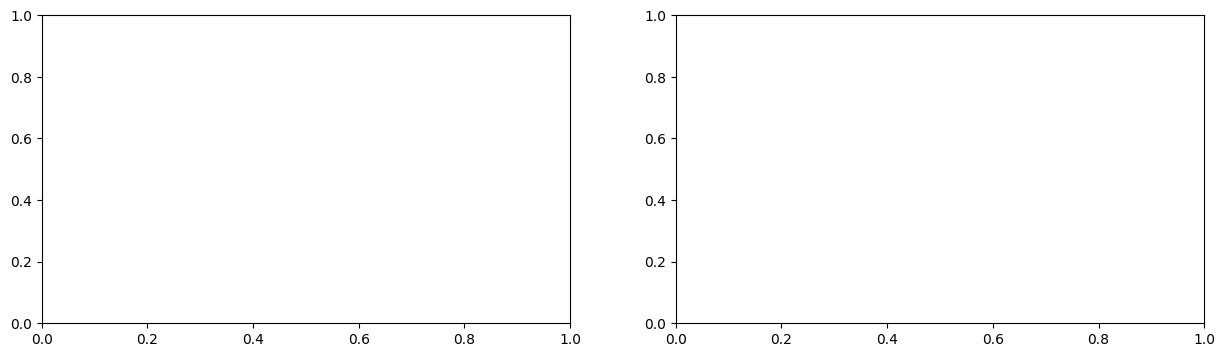

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import calendar
from sklearn.linear_model import LinearRegression

# Set the cyclone names and the number of days for the time delta
cyclone_names = ['BATSIRAI', 'FREDDY']
lag = 14

# Grid values
grids = ['MG21224000157', 'MG12000000014']

# Calculate historical averages
def calculate_historical_average(df_date, grid3):
    hist_avg_df = pd.DataFrame()
    for year in range(2013, 2022):
        for month in range(1, 12):
            num_days = calendar.monthrange(year, month)[1]
            for day in range(1, num_days + 1):
                current_date = pd.to_datetime(f"{year}-{month:02d}-{day:02d}")
                if grid3 in df_date.index:
                    specific_data = df_date.loc[grid3, current_date.strftime('%Y-%m-%d')]
                    hist_avg_df.at[f'{month:02d}-{day:02d}', year] = specific_data.mean()
    hist_avg_df[f'{cyclone_name} Historical Average'] = hist_avg_df.mean(axis=1)
    return hist_avg_df

# Assuming the necessary data is already loaded into landfall_df and df_date
fig, axs = plt.subplots(len(grids), len(cyclone_names), figsize=(15, len(grids) * 4), sharex='col')

for j, cyclone_name in enumerate(cyclone_names):
    if cyclone_name in landfall_df['Cyclone'].values:
        if cyclone_name == 'BATSIRAI':
            cyclone_onset = pd.to_datetime(landfall_df.loc[landfall_df['Cyclone'] == cyclone_name, 'Onset_Date_plus1d'].values[0])
        elif cyclone_name == 'FREDDY':
            cyclone_onset = pd.to_datetime(landfall_df.loc[landfall_df['Cyclone'] == cyclone_name, 'Onset_Date_plus12d'].values[0])
        
        cyclone_onset_str = cyclone_onset.strftime('%m-%d')
        start_date = cyclone_onset - pd.Timedelta(days=lag)
        end_date = cyclone_onset + pd.Timedelta(days=lag)
        date_range = pd.date_range(start=start_date, end=end_date)

        for i, grid3 in enumerate(grids):
            ax = axs[i, j]

            if grid3 not in df_date.index:
                print(f"Grid '{grid3}' not found in the dataset.")
                continue

            specific_row = df_date.loc[grid3, date_range]

            # Plot grid values
            ax.plot([date.strftime('%m-%d') for date in date_range], specific_row, label='Cyclone', color='steelblue')

            pre_data_grid3 = specific_row[date_range < cyclone_onset]
            post_data_grid3 = specific_row[date_range >= cyclone_onset]

            X_pre_grid3 = np.arange(len(pre_data_grid3)).reshape(-1, 1)
            y_pre_grid3 = pre_data_grid3.values.reshape(-1, 1)
            X_post_grid3 = np.arange(len(post_data_grid3)).reshape(-1, 1)
            y_post_grid3 = post_data_grid3.values.reshape(-1, 1)

            model_pre_grid3 = LinearRegression().fit(X_pre_grid3, y_pre_grid3)
            model_post_grid3 = LinearRegression().fit(X_post_grid3, y_post_grid3)

            slope_pre_grid3 = model_pre_grid3.coef_[0][0]
            slope_post_grid3 = model_post_grid3.coef_[0][0]

            ax.plot([date.strftime('%m-%d') for date in date_range[:len(pre_data_grid3)]], model_pre_grid3.predict(X_pre_grid3), linestyle='--', color='blue', label='Pre-Cyclone Regression Line')
            ax.plot([date.strftime('%m-%d') for date in date_range[-len(post_data_grid3):]], model_post_grid3.predict(X_post_grid3), linestyle='--', color='darkblue', label='Post-Cyclone Regression Line')

            # Calculate historical averages
            hist_avg_df = calculate_historical_average(df_date, grid3)
            avg_data = hist_avg_df.loc[hist_avg_df.index.isin([date.strftime('%m-%d') for date in date_range]), f'{cyclone_name} Historical Average']
            ax.plot(avg_data.index, avg_data, label='Historical Average', color='orange')

            pre_data_hist = avg_data[date_range < cyclone_onset]
            post_data_hist = avg_data[date_range >= cyclone_onset]

            X_pre_hist = np.arange(len(pre_data_hist)).reshape(-1, 1)
            y_pre_hist = pre_data_hist.values.reshape(-1, 1)
            X_post_hist = np.arange(len(post_data_hist)).reshape(-1, 1)
            y_post_hist = post_data_hist.values.reshape(-1, 1)

            model_pre_hist = LinearRegression().fit(X_pre_hist, y_pre_hist)
            model_post_hist = LinearRegression().fit(X_post_hist, y_post_hist)

            slope_pre_hist = model_pre_hist.coef_[0][0]
            slope_post_hist = model_post_hist.coef_[0][0]

            ax.plot([date.strftime('%m-%d') for date in date_range[:len(pre_data_hist)]], model_pre_hist.predict(X_pre_hist), linestyle='--', color='green', label='Historical Pre-Cyclone Regression Line')
            ax.plot([date.strftime('%m-%d') for date in date_range[-len(post_data_hist):]], model_post_hist.predict(X_post_hist), linestyle='--', color='darkgreen', label='Historical Post-Cyclone Regression Line')

            cyclone_slope_diff_percent = (slope_post_grid3 - slope_pre_grid3) / abs(slope_pre_grid3) * 100
            hist_slope_diff_percent = (slope_post_hist - slope_pre_hist) / abs(slope_pre_hist) * 100

            # Annotations for slope percent differences
            ax.annotate(f'Cyclone Slope Diff: {cyclone_slope_diff_percent:.2f}%', xy=(0.98, 0.95), xycoords='axes fraction', textcoords="offset points", xytext=(-20,0), ha='right', color='blue')
            ax.annotate(f'Historical Slope Diff: {hist_slope_diff_percent:.2f}%', xy=(0.98, 0.90), xycoords='axes fraction', textcoords="offset points", xytext=(-20,0), ha='right', color='green')

            # Ensure pre_dates and post_dates are correctly defined
            pre_dates_str = [date.strftime('%m-%d') for date in date_range[:len(pre_data_grid3)]]
            post_dates_str = [date.strftime('%m-%d') for date in date_range[-len(post_data_grid3):]]

            # Convert dates for annotation positioning
            pre_date_for_annotation = pre_dates_str[-5]
            post_date_for_annotation = post_dates_str[8]

            # Annotation for slopes with corrected placement
            ax.annotate(f'slope: {slope_pre_grid3:.3f}', xy=(pre_date_for_annotation, model_pre_grid3.predict(X_pre_grid3)[-1][0]), xycoords='data', textcoords="offset points", xytext=(0,10), ha='center', color='blue')
            ax.annotate(f'slope: {slope_post_grid3:.3f}', xy=(post_date_for_annotation, model_post_grid3.predict(X_post_grid3)[-1][0]), xycoords='data', textcoords="offset points", xytext=(0,-10), ha='center', color='darkblue')

            pre_hist_dates_str = [date.strftime('%m-%d') for date in date_range[:len(pre_data_hist)]]
            post_hist_dates_str = [date.strftime('%m-%d') for date in date_range[-len(post_data_hist):]]

            ax.annotate(f'slope: {slope_pre_hist:.3f}', xy=(pre_hist_dates_str[-5], model_pre_hist.predict(X_pre_hist)[-1][0]), xycoords='data', textcoords="offset points", xytext=(0,10), ha='center', color='green')
            ax.annotate(f'slope: {slope_post_hist:.3f}', xy=(post_hist_dates_str[3], model_post_hist.predict(X_post_hist)[1][0]), xycoords='data', textcoords="offset points", xytext=(0,-10), ha='center', color='darkgreen')

            if i == 0:  # Set the cyclone name as the column title for the top row
                ax.set_title(cyclone_name)

            ax.axvline(x=cyclone_onset_str, color='red', linestyle='-', label='Onset Date')
            ax.tick_params(axis='x', rotation=50)

# Add the legend to the figure and adjust the position
handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=3)  # Adjust bbox_to_anchor to move the legend

# Add x-axis label to the last subplot in each column
for ax in axs[-1, :]:
    ax.set_xlabel('Date (Month-Day)')

# Set grid values as row titles
for i, grid3 in enumerate(grids):
    axs[i, 0].set_ylabel(grid3, rotation=50, labelpad=30)

plt.tight_layout(rect=[0, 0, 1, 0.97])  # Adjust the rect parameter to accommodate the legend
plt.savefig('cyclone_data_analysis_multiplot.png', dpi=300)  # Adjust the path as needed
plt.show()


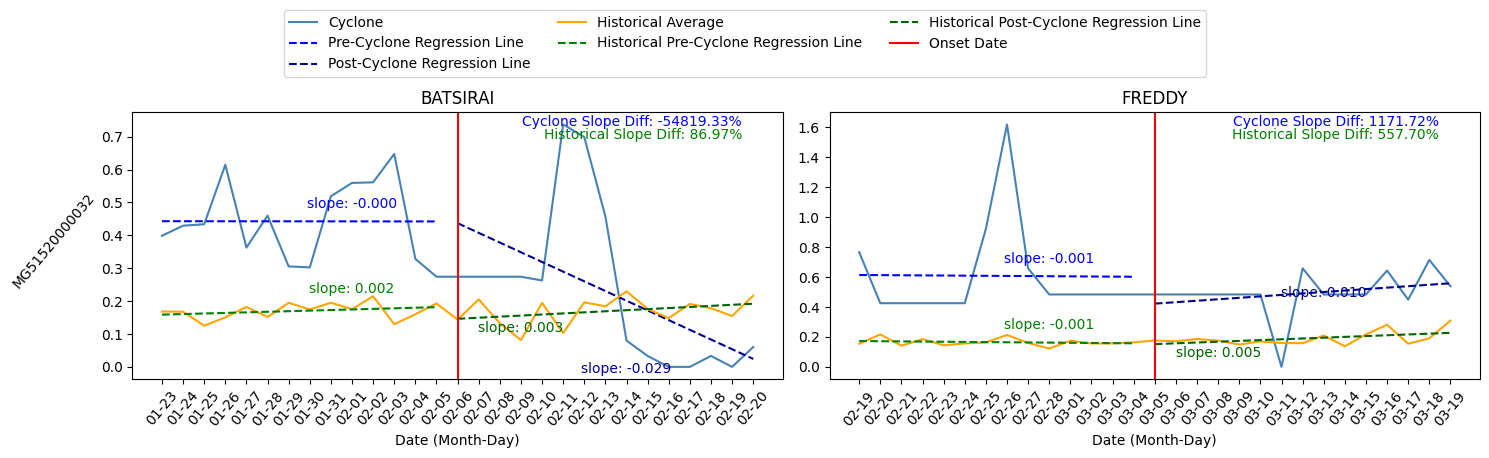

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import calendar
from sklearn.linear_model import LinearRegression

# Set the cyclone names and the number of days for the time delta
cyclone_names = ['BATSIRAI', 'FREDDY']
lag = 14

# Grid values
grids = ['MG51520000032']

# Calculate historical averages
def calculate_historical_average(df_date, grid3):
    hist_avg_df = pd.DataFrame()
    for year in range(2013, 2022):
        for month in range(1, 13):  # Adjusted to include December
            num_days = calendar.monthrange(year, month)[1]
            for day in range(1, num_days + 1):
                current_date = pd.to_datetime(f"{year}-{month:02d}-{day:02d}")
                if grid3 in df_date.index:
                    specific_data = df_date.loc[grid3, current_date.strftime('%Y-%m-%d')]
                    hist_avg_df.at[f'{month:02d}-{day:02d}', year] = specific_data.mean()
    hist_avg_df[f'{cyclone_name} Historical Average'] = hist_avg_df.mean(axis=1)
    return hist_avg_df

# Assuming the necessary data is already loaded into landfall_df and df_date
fig, axs = plt.subplots(len(grids), len(cyclone_names), figsize=(15, len(grids) * 4), sharex='col')

# Ensure axs is always a 2D array for consistent indexing
if len(grids) == 1 and len(cyclone_names) == 1:
    axs = np.array([[axs]])
elif len(grids) == 1 or len(cyclone_names) == 1:
    axs = np.expand_dims(axs, axis=0 if len(grids) == 1 else 1)

for j, cyclone_name in enumerate(cyclone_names):
    if cyclone_name in landfall_df['Cyclone'].values:
        if cyclone_name == 'BATSIRAI':
            cyclone_onset = pd.to_datetime(landfall_df.loc[landfall_df['Cyclone'] == cyclone_name, 'Onset_Date_plus1d'].values[0])
        elif cyclone_name == 'FREDDY':
            cyclone_onset = pd.to_datetime(landfall_df.loc[landfall_df['Cyclone'] == cyclone_name, 'Onset_Date_plus12d'].values[0])
        
        cyclone_onset_str = cyclone_onset.strftime('%m-%d')
        start_date = cyclone_onset - pd.Timedelta(days=lag)
        end_date = cyclone_onset + pd.Timedelta(days=lag)
        date_range = pd.date_range(start=start_date, end=end_date)

        for i, grid3 in enumerate(grids):
            ax = axs[i, j]

            if grid3 not in df_date.index:
                print(f"Grid '{grid3}' not found in the dataset.")
                continue

            specific_row = df_date.loc[grid3, date_range]

            # Plot grid values
            ax.plot([date.strftime('%m-%d') for date in date_range], specific_row, label='Cyclone', color='steelblue')

            pre_data_grid3 = specific_row[date_range < cyclone_onset]
            post_data_grid3 = specific_row[date_range >= cyclone_onset]

            X_pre_grid3 = np.arange(len(pre_data_grid3)).reshape(-1, 1)
            y_pre_grid3 = pre_data_grid3.values.reshape(-1, 1)
            X_post_grid3 = np.arange(len(post_data_grid3)).reshape(-1, 1)
            y_post_grid3 = post_data_grid3.values.reshape(-1, 1)

            model_pre_grid3 = LinearRegression().fit(X_pre_grid3, y_pre_grid3)
            model_post_grid3 = LinearRegression().fit(X_post_grid3, y_post_grid3)

            slope_pre_grid3 = model_pre_grid3.coef_[0][0]
            slope_post_grid3 = model_post_grid3.coef_[0][0]

            ax.plot([date.strftime('%m-%d') for date in date_range[:len(pre_data_grid3)]], model_pre_grid3.predict(X_pre_grid3), linestyle='--', color='blue', label='Pre-Cyclone Regression Line')
            ax.plot([date.strftime('%m-%d') for date in date_range[-len(post_data_grid3):]], model_post_grid3.predict(X_post_grid3), linestyle='--', color='darkblue', label='Post-Cyclone Regression Line')

            # Calculate historical averages
            hist_avg_df = calculate_historical_average(df_date, grid3)
            avg_data = hist_avg_df.loc[hist_avg_df.index.isin([date.strftime('%m-%d') for date in date_range]), f'{cyclone_name} Historical Average']
            ax.plot(avg_data.index, avg_data, label='Historical Average', color='orange')

            pre_data_hist = avg_data[date_range < cyclone_onset]
            post_data_hist = avg_data[date_range >= cyclone_onset]

            X_pre_hist = np.arange(len(pre_data_hist)).reshape(-1, 1)
            y_pre_hist = pre_data_hist.values.reshape(-1, 1)
            X_post_hist = np.arange(len(post_data_hist)).reshape(-1, 1)
            y_post_hist = post_data_hist.values.reshape(-1, 1)

            model_pre_hist = LinearRegression().fit(X_pre_hist, y_pre_hist)
            model_post_hist = LinearRegression().fit(X_post_hist, y_post_hist)

            slope_pre_hist = model_pre_hist.coef_[0][0]
            slope_post_hist = model_post_hist.coef_[0][0]

            ax.plot([date.strftime('%m-%d') for date in date_range[:len(pre_data_hist)]], model_pre_hist.predict(X_pre_hist), linestyle='--', color='green', label='Historical Pre-Cyclone Regression Line')
            ax.plot([date.strftime('%m-%d') for date in date_range[-len(post_data_hist):]], model_post_hist.predict(X_post_hist), linestyle='--', color='darkgreen', label='Historical Post-Cyclone Regression Line')

            cyclone_slope_diff_percent = (slope_post_grid3 - slope_pre_grid3) / abs(slope_pre_grid3) * 100
            hist_slope_diff_percent = (slope_post_hist - slope_pre_hist) / abs(slope_pre_hist) * 100

            # Annotations for slope percent differences
            ax.annotate(f'Cyclone Slope Diff: {cyclone_slope_diff_percent:.2f}%', xy=(0.98, 0.95), xycoords='axes fraction', textcoords="offset points", xytext=(-20,0), ha='right', color='blue')
            ax.annotate(f'Historical Slope Diff: {hist_slope_diff_percent:.2f}%', xy=(0.98, 0.90), xycoords='axes fraction', textcoords="offset points", xytext=(-20,0), ha='right', color='green')

            # Ensure pre_dates and post_dates are correctly defined
            pre_dates_str = [date.strftime('%m-%d') for date in date_range[:len(pre_data_grid3)]]
            post_dates_str = [date.strftime('%m-%d') for date in date_range[-len(post_data_grid3):]]

            # Convert dates for annotation positioning
            pre_date_for_annotation = pre_dates_str[-5]
            post_date_for_annotation = post_dates_str[8]

            # Annotation for slopes with corrected placement
            ax.annotate(f'slope: {slope_pre_grid3:.3f}', xy=(pre_date_for_annotation, model_pre_grid3.predict(X_pre_grid3)[-1][0]), xycoords='data', textcoords="offset points", xytext=(0,10), ha='center', color='blue')
            ax.annotate(f'slope: {slope_post_grid3:.3f}', xy=(post_date_for_annotation, model_post_grid3.predict(X_post_grid3)[-1][0]), xycoords='data', textcoords="offset points", xytext=(0,-10), ha='center', color='darkblue')

            pre_hist_dates_str = [date.strftime('%m-%d') for date in date_range[:len(pre_data_hist)]]
            post_hist_dates_str = [date.strftime('%m-%d') for date in date_range[-len(post_data_hist):]]

            ax.annotate(f'slope: {slope_pre_hist:.3f}', xy=(pre_hist_dates_str[-5], model_pre_hist.predict(X_pre_hist)[-1][0]), xycoords='data', textcoords="offset points", xytext=(0,10), ha='center', color='green')
            ax.annotate(f'slope: {slope_post_hist:.3f}', xy=(post_hist_dates_str[3], model_post_hist.predict(X_post_hist)[1][0]), xycoords='data', textcoords="offset points", xytext=(0,-10), ha='center', color='darkgreen')

            if i == 0:  # Set the cyclone name as the column title for the top row
                ax.set_title(cyclone_name)

            ax.axvline(x=cyclone_onset_str, color='red', linestyle='-', label='Onset Date')
            ax.tick_params(axis='x', rotation=50)

# Add the legend to the figure and adjust the position
handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=3)  # Adjust bbox_to_anchor to move the legend

# Add x-axis label to the last subplot in each column
for ax in axs[-1, :]:
    ax.set_xlabel('Date (Month-Day)')

# Set grid values as row titles
for i, grid3 in enumerate(grids):
    axs[i, 0].set_ylabel(grid3, rotation=50, labelpad=30)

plt.tight_layout(rect=[0, 0, 1, 0.97])  # Adjust the rect parameter to accommodate the legend
plt.savefig('cyclone_data_analysis_multiplot.png', dpi=300)  # Adjust the path as needed
plt.show()
